# 01 · Descarga de datos de brecha salarial — API SIMEL

Descargamos los 10 datasets de brecha salarial de género disponibles en la API SDMX del SIMEL-INE.
**Sin registro ni credenciales requeridas.**

In [1]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from simel_client import SIMELClient

sns.set_theme(style='whitegrid', font_scale=1.05)
pd.set_option('display.float_format', '{:.2f}'.format)
client = SIMELClient()
os.makedirs('data', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)
print('Cliente SIMEL listo.')

Cliente SIMEL listo.


In [2]:
DATASETS = [
    'DF_BGYMEDIOOCU',           # brecha ingreso medio por región
    'DF_BGYMEDIOOCU_EDU',       # por nivel educativo
    'DF_BGYMEDIOOCU_EDAD',      # por tramo etario
    'DF_BGYMEDIOOCU_RAMA',      # por rama de actividad económica
    'DF_BGYMEDIOOCU_CIUO',      # por grupo ocupacional
    'DF_BGYMEDIOOCU_TRAMOHORA', # por horas trabajadas
    'DF_BGYMEDIOOCU_CISE',      # por categoría ocupacional
    'DF_BGYHDEP_CISE_EDU',      # brecha por hora según educación
    'DF_BGYHDEP_CISE_EDAD',     # brecha por hora según edad
    'DF_BGREIMPROMSP',          # brecha en remuneración imponible AFP
]

print('Descargando 10 datasets de brecha salarial desde SIMEL-INE...')
datos = client.get_multiple(DATASETS)

for nombre, df in datos.items():
    df.to_csv(f'data/{nombre}.csv', index=False, encoding='utf-8-sig')
print('\nDatos guardados en data/')

Descargando 10 datasets de brecha salarial desde SIMEL-INE...
  → Descargando DF_BGYMEDIOOCU... 

✓ (255 filas)
  → Descargando DF_BGYMEDIOOCU_EDU... 

✓ (1773 filas)
  → Descargando DF_BGYMEDIOOCU_EDAD... 

✓ (1785 filas)
  → Descargando DF_BGYMEDIOOCU_RAMA... 

✓ (3828 filas)
  → Descargando DF_BGYMEDIOOCU_CIUO... 

...

✓ (1237 filas)
  → Descargando DF_BGYMEDIOOCU_CISE... 

✓ (1440 filas)
  → Descargando DF_BGYHDEP_CISE_EDU... 

✓ (333 filas)
  → Descargando DF_BGYHDEP_CISE_EDAD... 

✓ (315 filas)
  → Descargando DF_BGREIMPROMSP... 

✗ Error: 404 Client Error: Not Found for url: https://sdmx.ine.gob.cl/rest/data/CL01,DF_BGREIMPROMSP,1.0?format=csv

Datos guardados en data/


## El indicador: ¿qué mide la brecha?

$$\text{Brecha} = \frac{\text{Ingreso}_H - \text{Ingreso}_M}{\text{Ingreso}_H} \times 100$$

- **Positivo**: hombres ganan más (situación habitual)
- **Negativo**: mujeres ganan más (ocurre en algunos grupos específicos)
- **Cero**: paridad perfecta

Evolución brecha salarial nacional:
 AÑO  Brecha (%)
2010      -32.85
2011      -34.96
2012      -33.32
2013      -33.96
2014      -29.69
2015      -31.14
2016      -30.97
2017      -29.70
2018      -27.10
2019      -28.06
2020      -20.36
2021      -21.74
2022      -25.53
2023      -23.34
2024      -24.44


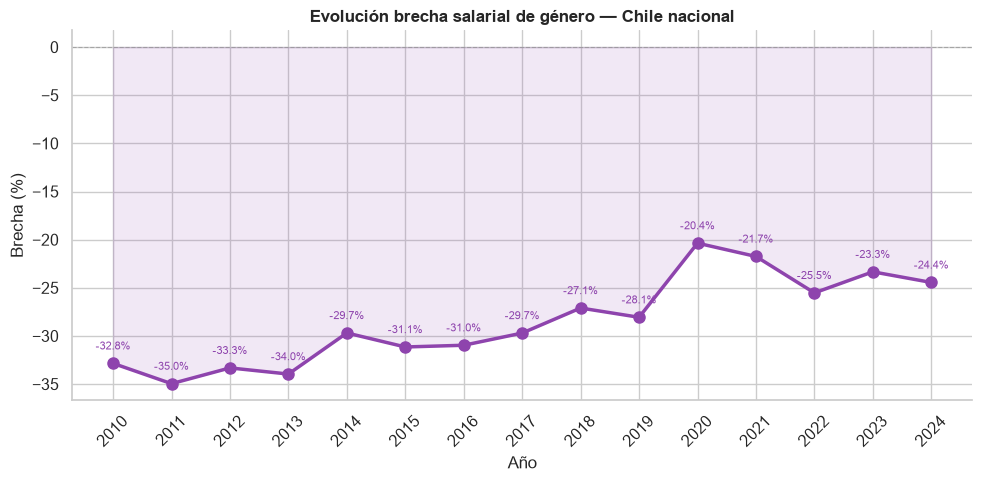

In [3]:
# Brecha nacional por año
nac = datos['DF_BGYMEDIOOCU']
nac_t = nac[nac['AREA_REF']=='_T'].sort_values('AÑO')
print('Evolución brecha salarial nacional:')
print(nac_t[['AÑO','OBS_VALUE']].rename(columns={'OBS_VALUE':'Brecha (%)'}).to_string(index=False))

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(nac_t['AÑO'], nac_t['OBS_VALUE'], 'o-', color='#8e44ad', linewidth=2.5, markersize=8)
ax.fill_between(nac_t['AÑO'], nac_t['OBS_VALUE'], alpha=0.12, color='#8e44ad')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
for _, row in nac_t.iterrows():
    ax.annotate(f"{row['OBS_VALUE']:.1f}%", (row['AÑO'],row['OBS_VALUE']),
                textcoords='offset points', xytext=(0,10), ha='center', fontsize=8, color='#8e44ad')
ax.set_title('Evolución brecha salarial de género — Chile nacional', fontsize=12, fontweight='bold')
ax.set_ylabel('Brecha (%)'); ax.set_xlabel('Año')
ax.set_xticks(nac_t['AÑO'].unique())
plt.setp(ax.get_xticklabels(), rotation=45)
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/brecha_nacional.png', dpi=150, bbox_inches='tight')
plt.show()

## Brecha por región

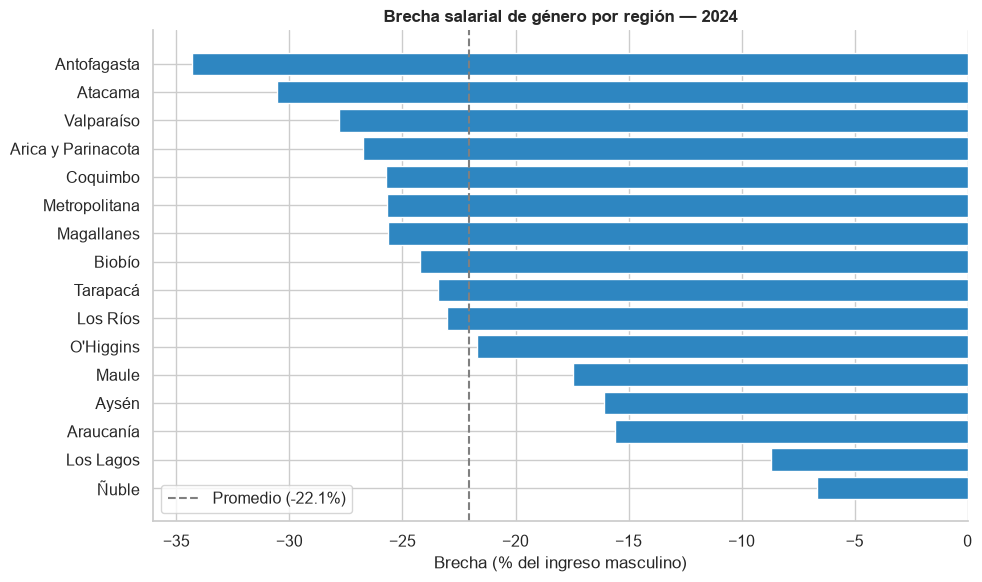

In [4]:
anio_max = datos['DF_BGYMEDIOOCU']['AÑO'].max()
reg = datos['DF_BGYMEDIOOCU'][(datos['DF_BGYMEDIOOCU']['AÑO']==anio_max)&(datos['DF_BGYMEDIOOCU']['AREA_REF']!='_T')]
reg = reg.sort_values('OBS_VALUE', ascending=False)

fig, ax = plt.subplots(figsize=(10,6))
colores = ['#c0392b' if v>20 else '#e67e22' if v>10 else '#2e86c1' for v in reg['OBS_VALUE']]
ax.barh(reg['REGION'], reg['OBS_VALUE'], color=colores, edgecolor='white')
ax.axvline(reg['OBS_VALUE'].mean(), color='gray', linestyle='--',
           label=f"Promedio ({reg['OBS_VALUE'].mean():.1f}%)")
ax.set_title(f'Brecha salarial de género por región — {anio_max}', fontsize=12, fontweight='bold')
ax.set_xlabel('Brecha (% del ingreso masculino)'); ax.legend()
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/brecha_por_region.png', dpi=150, bbox_inches='tight')
plt.show()

## Resumen de datasets descargados

In [5]:
resumen = []
for k, v in datos.items():
    anio_min = v['AÑO'].min() if 'AÑO' in v.columns else '—'
    anio_max = v['AÑO'].max() if 'AÑO' in v.columns else '—'
    resumen.append({'Dataset': k, 'Filas': len(v), 'Período': f'{anio_min:.0f}–{anio_max:.0f}' if isinstance(anio_min, float) else '—'})
pd.DataFrame(resumen)

,Dataset,Filas,Período
0,DF_BGYMEDIOOCU,255,—
1,DF_BGYMEDIOOCU_EDU,1773,—
2,DF_BGYMEDIOOCU_EDAD,1785,—
3,DF_BGYMEDIOOCU_RAMA,3828,—
4,DF_BGYMEDIOOCU_CIUO,1434,—
5,DF_BGYMEDIOOCU_TRAMOHORA,1237,—
6,DF_BGYMEDIOOCU_CISE,1440,—
7,DF_BGYHDEP_CISE_EDU,333,—
8,DF_BGYHDEP_CISE_EDAD,315,—
